# Primer Entregable del Proyecto de Investigación

## Selección de Base de Datos, Análisis Exploratorio e Implementación de Modelo Base

**Asignatura:** Machine Learning  
**Autor:** Jassan Alberto Arteta Chavarro  
**Universidad:** Universidad del Norte  
**Periodo:** 2026-30  

---

## Objetivo

Establecer las bases del proyecto de investigación mediante:

1. La selección de una base de datos pertinente.
2. La realización de un Análisis Exploratorio de Datos (EDA) riguroso y exhaustivo.
3. La implementación de un modelo base como referencia inicial.
4. La comparación del modelo base con una línea base trivial.

In [5]:
# ============================================================
# CONFIGURACIÓN GENERAL DEL PROYECTO
# Ruta C: Regresión Temporal - Criptomonedas
# Fuente maestra: Binance Spot
# ============================================================

import sys
import random
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import statsmodels
import requests

from sklearn.model_selection import TimeSeriesSplit

# Reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")

# Configuración del dataset
DATA_SOURCE = "Binance Spot"

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "XRPUSDT",
    "SOLUSDT"
]

INTERVAL = "1h"
TIMEZONE = "UTC"

# Carpetas
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Información del entorno
print("=" * 70)
print("CONFIGURACIÓN DEL PROYECTO DE MACHINE LEARNING")
print("RUTA C: REGRESIÓN TEMPORAL - CRIPTOMONEDAS")
print("=" * 70)

print("\nFuente de datos:")
print(DATA_SOURCE)

print("\nCriptoactivos:")
for symbol in SYMBOLS:
    print("-", symbol)

print("\nFrecuencia:")
print(INTERVAL)

print("\nZona horaria:")
print(TIMEZONE)

print("\nSemilla:")
print(SEED)

print("\nPython:")
print(sys.version)

print("\nIntérprete:")
print(sys.executable)

print("\nVersiones:")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Statsmodels:", statsmodels.__version__)
print("Requests:", requests.__version__)

print("\nFecha de ejecución:")
print(datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC"))

CONFIGURACIÓN DEL PROYECTO DE MACHINE LEARNING
RUTA C: REGRESIÓN TEMPORAL - CRIPTOMONEDAS

Fuente de datos:
Binance Spot

Criptoactivos:
- BTCUSDT
- ETHUSDT
- BNBUSDT
- XRPUSDT
- SOLUSDT

Frecuencia:
1h

Zona horaria:
UTC

Semilla:
42

Python:
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]

Intérprete:
c:\Users\Lenovo\miniconda3\envs\ml_venv\python.exe

Versiones:
NumPy: 2.5.3
Pandas: 3.0.5
Matplotlib: 3.11.2
SciPy: 1.18.1
Scikit-learn: 1.9.1
Statsmodels: 0.15.0
Requests: 2.34.2

Fecha de ejecución:
2026-09-20 15:22:08 UTC


In [6]:
# ============================================================
# PRUEBA DE CONEXIÓN CON BINANCE
# ============================================================

BASE_URL = "https://data-api.binance.vision"

endpoint = f"{BASE_URL}/api/v3/klines"

params = {
    "symbol": "BTCUSDT",
    "interval": "1h",
    "limit": 10
}

response = requests.get(endpoint, params=params, timeout=30)
response.raise_for_status()

data_test = response.json()

print("Conexión exitosa con Binance")
print("Número de velas descargadas:", len(data_test))
print("\nPrimera observación:")
print(data_test[0])

Conexión exitosa con Binance
Número de velas descargadas: 10

Primera observación:
[1789884000000, '80494.31000000', '80607.50000000', '80227.27000000', '80309.44000000', '458.02321000', 1789887599999, '36819834.92252950', 64977, '217.66375000', '17496980.53662470', '0']


In [ ]:
# ============================================================
# DESCARGA HISTÓRICA DE DATOS OHLCV DESDE BINANCE SPOT
# ============================================================

import time

BASE_URL = "https://data-api.binance.vision"
KLINES_ENDPOINT = f"{BASE_URL}/api/v3/klines"

# Periodo amplio.
# SOL comienza más tarde que BTC, ETH, etc.
START_DATE = "2020-01-01"
END_DATE = "2026-09-20"

KLINE_COLUMNS = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
    "ignore"
]


def download_binance_klines(
    symbol,
    interval="1h",
    start_date=START_DATE,
    end_date=END_DATE
):
    """
    Descarga datos históricos de velas de Binance utilizando
    paginación cronológica.

    Cada solicitud obtiene hasta 1000 observaciones.
    """

    start_ms = int(
        pd.Timestamp(start_date, tz="UTC").timestamp() * 1000
    )

    end_ms = int(
        pd.Timestamp(end_date, tz="UTC").timestamp() * 1000
    )

    all_data = []

    print("=" * 70)
    print(f"Descargando: {symbol}")
    print(f"Intervalo:   {interval}")
    print(f"Desde:       {start_date}")
    print(f"Hasta:       {end_date}")
    print("=" * 70)

    while start_ms < end_ms:

        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1000
        }

        response = requests.get(
            KLINES_ENDPOINT,
            params=params,
            timeout=30
        )

        response.raise_for_status()

        data = response.json()

        if len(data) == 0:
            break

        all_data.extend(data)

        # Próxima consulta: inmediatamente después
        # de la última vela descargada
        start_ms = data[-1][0] + 1

        print(
            f"\rObservaciones descargadas: {len(all_data):,}",
            end=""
        )

        time.sleep(0.05)

    print()

    # --------------------------------------------------------
    # Construcción del DataFrame
    # --------------------------------------------------------

    df = pd.DataFrame(
        all_data,
        columns=KLINE_COLUMNS
    )

    if df.empty:
        print(f"No se encontraron datos para {symbol}")
        return df

    # Identificador del activo
    df.insert(0, "symbol", symbol)

    # --------------------------------------------------------
    # Conversión temporal
    # --------------------------------------------------------

    df["open_time"] = pd.to_datetime(
        df["open_time"],
        unit="ms",
        utc=True
    )

    df["close_time"] = pd.to_datetime(
        df["close_time"],
        unit="ms",
        utc=True
    )

    # --------------------------------------------------------
    # Conversión numérica
    # --------------------------------------------------------

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "taker_buy_base_volume",
        "taker_buy_quote_volume"
    ]

    df[numeric_columns] = (
        df[numeric_columns]
        .apply(pd.to_numeric, errors="coerce")
    )

    df["number_of_trades"] = pd.to_numeric(
        df["number_of_trades"],
        errors="coerce"
    )

    # Columna que Binance no utiliza para análisis
    df = df.drop(columns=["ignore"])

    # Orden cronológico
    df = (
        df.sort_values("open_time")
        .drop_duplicates(
            subset=["symbol", "open_time"]
        )
        .reset_index(drop=True)
    )

    return df

In [8]:
# ============================================================
# FUNCIÓN PARA DESCARGAR DATOS HISTÓRICOS DE BINANCE
# ============================================================

import time

BASE_URL = "https://data-api.binance.vision"
KLINES_ENDPOINT = f"{BASE_URL}/api/v3/klines"

START_DATE = "2020-01-01"
END_DATE = "2026-09-20"

KLINE_COLUMNS = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
    "ignore"
]


def download_binance_klines(
    symbol,
    interval="1h",
    start_date=START_DATE,
    end_date=END_DATE
):
    start_ms = int(
        pd.Timestamp(start_date, tz="UTC").timestamp() * 1000
    )

    end_ms = int(
        pd.Timestamp(end_date, tz="UTC").timestamp() * 1000
    )

    all_data = []

    print("=" * 70)
    print(f"Descargando: {symbol}")
    print(f"Intervalo:   {interval}")
    print(f"Desde:       {start_date}")
    print(f"Hasta:       {end_date}")
    print("=" * 70)

    while start_ms < end_ms:

        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1000
        }

        response = requests.get(
            KLINES_ENDPOINT,
            params=params,
            timeout=30
        )

        response.raise_for_status()

        data = response.json()

        if len(data) == 0:
            break

        all_data.extend(data)

        start_ms = data[-1][0] + 1

        print(
            f"\rObservaciones descargadas: {len(all_data):,}",
            end=""
        )

        time.sleep(0.05)

    print()

    df = pd.DataFrame(
        all_data,
        columns=KLINE_COLUMNS
    )

    if df.empty:
        print(f"No se encontraron datos para {symbol}")
        return df

    df.insert(0, "symbol", symbol)

    df["open_time"] = pd.to_datetime(
        df["open_time"],
        unit="ms",
        utc=True
    )

    df["close_time"] = pd.to_datetime(
        df["close_time"],
        unit="ms",
        utc=True
    )

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "taker_buy_base_volume",
        "taker_buy_quote_volume"
    ]

    df[numeric_columns] = (
        df[numeric_columns]
        .apply(pd.to_numeric, errors="coerce")
    )

    df["number_of_trades"] = pd.to_numeric(
        df["number_of_trades"],
        errors="coerce"
    )

    df = df.drop(columns=["ignore"])

    df = (
        df.sort_values("open_time")
        .drop_duplicates(
            subset=["symbol", "open_time"]
        )
        .reset_index(drop=True)
    )

    return df

In [9]:
# ============================================================
# DESCARGA DE LOS CINCO CRIPTOACTIVOS
# ============================================================

crypto_data = {}

for symbol in SYMBOLS:

    df_symbol = download_binance_klines(
        symbol=symbol,
        interval=INTERVAL,
        start_date=START_DATE,
        end_date=END_DATE
    )

    crypto_data[symbol] = df_symbol

    # Guardar datos crudos individualmente
    file_path = RAW_DIR / f"{symbol}_{INTERVAL}.csv"

    df_symbol.to_csv(
        file_path,
        index=False
    )

    print(
        f"{symbol}: {len(df_symbol):,} observaciones "
        f"guardadas en {file_path}"
    )

Descargando: BTCUSDT
Intervalo:   1h
Desde:       2020-01-01
Hasta:       2026-09-20
Observaciones descargadas: 58,865
BTCUSDT: 58,865 observaciones guardadas en data\raw\BTCUSDT_1h.csv
Descargando: ETHUSDT
Intervalo:   1h
Desde:       2020-01-01
Hasta:       2026-09-20
Observaciones descargadas: 58,865
ETHUSDT: 58,865 observaciones guardadas en data\raw\ETHUSDT_1h.csv
Descargando: BNBUSDT
Intervalo:   1h
Desde:       2020-01-01
Hasta:       2026-09-20
Observaciones descargadas: 58,865
BNBUSDT: 58,865 observaciones guardadas en data\raw\BNBUSDT_1h.csv
Descargando: XRPUSDT
Intervalo:   1h
Desde:       2020-01-01
Hasta:       2026-09-20
Observaciones descargadas: 58,865
XRPUSDT: 58,865 observaciones guardadas en data\raw\XRPUSDT_1h.csv
Descargando: SOLUSDT
Intervalo:   1h
Desde:       2020-01-01
Hasta:       2026-09-20
Observaciones descargadas: 53,519
SOLUSDT: 53,519 observaciones guardadas en data\raw\SOLUSDT_1h.csv


In [10]:
# ============================================================
# RESUMEN Y CONTROL DE CALIDAD DE LOS DATOS DESCARGADOS
# ============================================================

summary = []

for symbol, df_symbol in crypto_data.items():

    summary.append({
        "Criptoactivo": symbol,
        "Observaciones": len(df_symbol),
        "Fecha inicial": df_symbol["open_time"].min(),
        "Fecha final": df_symbol["open_time"].max(),
        "Variables": df_symbol.shape[1],
        "Valores faltantes": int(df_symbol.isna().sum().sum()),
        "Duplicados": int(
            df_symbol.duplicated(
                subset=["symbol", "open_time"]
            ).sum()
        )
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

print("=" * 75)
print("RESUMEN GENERAL DEL DATASET")
print("=" * 75)

print(
    f"Total de observaciones: "
    f"{summary_df['Observaciones'].sum():,}"
)

print(
    f"Número de criptoactivos: "
    f"{summary_df['Criptoactivo'].nunique()}"
)

print(
    f"Total de valores faltantes: "
    f"{summary_df['Valores faltantes'].sum():,}"
)

print(
    f"Total de duplicados: "
    f"{summary_df['Duplicados'].sum():,}"
)

print("=" * 75)

,Criptoactivo,Observaciones,Fecha inicial,Fecha final,Variables,Valores faltantes,Duplicados
0,BTCUSDT,58865,2020-01-01 00:00:00+00:00,2026-09-20 00:00:00+00:00,12,0,0
1,ETHUSDT,58865,2020-01-01 00:00:00+00:00,2026-09-20 00:00:00+00:00,12,0,0
2,BNBUSDT,58865,2020-01-01 00:00:00+00:00,2026-09-20 00:00:00+00:00,12,0,0
3,XRPUSDT,58865,2020-01-01 00:00:00+00:00,2026-09-20 00:00:00+00:00,12,0,0
4,SOLUSDT,53519,2020-08-11 06:00:00+00:00,2026-09-20 00:00:00+00:00,12,0,0


RESUMEN GENERAL DEL DATASET
Total de observaciones: 288,979
Número de criptoactivos: 5
Total de valores faltantes: 0
Total de duplicados: 0


In [12]:
# ============================================================
# CONSTRUCCIÓN DEL DATASET MAESTRO
# ============================================================

df_master = pd.concat(
    crypto_data.values(),
    ignore_index=True
)

df_master = (
    df_master
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

print("Dimensiones del dataset maestro:")
print(df_master.shape)

print(
    f"\nTotal de observaciones: "
    f"{len(df_master):,}"
)

print(
    f"Número de variables: "
    f"{df_master.shape[1]}"
)

display(df_master.head())

Dimensiones del dataset maestro:
(288979, 12)

Total de observaciones: 288,979
Número de variables: 12


,symbol,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume
0,BNBUSDT,2020-01-01 00:00:00+00:00,13.715900,13.721100,13.690300,13.698100,"62,016.690000",2020-01-01 00:59:59.999000+00:00,"849,861.709947",974,"40,644.000000","556,987.169809"
1,BNBUSDT,2020-01-01 01:00:00+00:00,13.698100,13.800000,13.695300,13.799500,"53,791.250000",2020-01-01 01:59:59.999000+00:00,"740,575.897325",1613,"31,233.620000","429,983.786527"
2,BNBUSDT,2020-01-01 02:00:00+00:00,13.798400,13.848800,13.790600,13.847800,"75,200.490000",2020-01-01 02:59:59.999000+00:00,"1,039,091.056988",1738,"50,428.790000","696,827.231512"
3,BNBUSDT,2020-01-01 03:00:00+00:00,13.846100,13.850000,13.785500,13.817000,"35,995.970000",2020-01-01 03:59:59.999000+00:00,"497,501.822769",784,"26,728.890000","369,440.277768"
4,BNBUSDT,2020-01-01 04:00:00+00:00,13.815700,13.826200,13.780100,13.792200,"34,409.550000",2020-01-01 04:59:59.999000+00:00,"475,128.475077",784,"21,646.900000","298,923.160759"


In [13]:
MASTER_FILE = PROCESSED_DIR / "crypto_binance_master_1h.csv"

df_master.to_csv(
    MASTER_FILE,
    index=False
)

print("Dataset maestro guardado en:")
print(MASTER_FILE)

Dataset maestro guardado en:
data\processed\crypto_binance_master_1h.csv


In [14]:
# ============================================================
# RESUMEN DEL DATASET MAESTRO
# ============================================================

print("=" * 75)
print("RESUMEN DEL DATASET MAESTRO")
print("=" * 75)

print(f"\nDimensiones: {df_master.shape}")
print(f"Total de observaciones: {len(df_master):,}")
print(f"Número de variables: {df_master.shape[1]}")

print("\nObservaciones por criptoactivo:")
print(df_master["symbol"].value_counts().sort_index())

print("\nFecha inicial por criptoactivo:")
print(
    df_master.groupby("symbol")["open_time"]
    .min()
)

print("\nFecha final por criptoactivo:")
print(
    df_master.groupby("symbol")["open_time"]
    .max()
)

print("\nValores faltantes por variable:")
print(df_master.isna().sum())

print("\nDuplicados por symbol + open_time:")
duplicados = df_master.duplicated(
    subset=["symbol", "open_time"]
).sum()
print(duplicados)

print("\nTipos de datos:")
print(df_master.dtypes)

print("=" * 75)

RESUMEN DEL DATASET MAESTRO

Dimensiones: (288979, 12)
Total de observaciones: 288,979
Número de variables: 12

Observaciones por criptoactivo:
symbol
BNBUSDT    58865
BTCUSDT    58865
ETHUSDT    58865
SOLUSDT    53519
XRPUSDT    58865
Name: count, dtype: int64

Fecha inicial por criptoactivo:
symbol
BNBUSDT   2020-01-01 00:00:00+00:00
BTCUSDT   2020-01-01 00:00:00+00:00
ETHUSDT   2020-01-01 00:00:00+00:00
SOLUSDT   2020-08-11 06:00:00+00:00
XRPUSDT   2020-01-01 00:00:00+00:00
Name: open_time, dtype: datetime64[ms, UTC]

Fecha final por criptoactivo:
symbol
BNBUSDT   2026-09-20 00:00:00+00:00
BTCUSDT   2026-09-20 00:00:00+00:00
ETHUSDT   2026-09-20 00:00:00+00:00
SOLUSDT   2026-09-20 00:00:00+00:00
XRPUSDT   2026-09-20 00:00:00+00:00
Name: open_time, dtype: datetime64[ms, UTC]

Valores faltantes por variable:
symbol                    0
open_time                 0
open                      0
high                      0
low                       0
close                     0
volume     

## 1.6 Tamaño de la muestra

El dataset maestro construido a partir de datos horarios del mercado Spot de Binance contiene inicialmente **288.979 observaciones** correspondientes a cinco criptoactivos:

| Criptoactivo | Observaciones |
|---|---:|
| BTCUSDT | 58.865 |
| ETHUSDT | 58.865 |
| BNBUSDT | 58.865 |
| XRPUSDT | 58.865 |
| SOLUSDT | 53.519 |

Los criptoactivos BTC, ETH, BNB y XRP disponen de observaciones desde el 1 de enero de 2020. Solana (SOL) presenta observaciones desde el 11 de agosto de 2020 a las 06:00 UTC.

Debido a que el análisis integrado requiere información disponible simultáneamente para los cinco criptoactivos, se utilizará posteriormente un **periodo temporal común**, cuyo inicio estará determinado por la primera observación disponible de SOLUSDT.

El tamaño de la muestra supera ampliamente las 50.000 observaciones consideradas como referencia mínima para el desarrollo del proyecto.

In [15]:
# ============================================================
# DETERMINACIÓN DEL PERIODO TEMPORAL COMÚN
# ============================================================

fecha_inicio_comun = (
    df_master
    .groupby("symbol")["open_time"]
    .min()
    .max()
)

fecha_final_comun = (
    df_master
    .groupby("symbol")["open_time"]
    .max()
    .min()
)

print("Inicio común:", fecha_inicio_comun)
print("Final común:", fecha_final_comun)

df_common = df_master[
    (df_master["open_time"] >= fecha_inicio_comun) &
    (df_master["open_time"] <= fecha_final_comun)
].copy()

df_common = (
    df_common
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

print("\nDimensiones del dataset común:")
print(df_common.shape)

print("\nObservaciones por criptoactivo:")
print(
    df_common["symbol"]
    .value_counts()
    .sort_index()
)

print(
    "\nTotal de observaciones:",
    f"{len(df_common):,}"
)

Inicio común: 2020-08-11 06:00:00+00:00
Final común: 2026-09-20 00:00:00+00:00

Dimensiones del dataset común:
(267595, 12)

Observaciones por criptoactivo:
symbol
BNBUSDT    53519
BTCUSDT    53519
ETHUSDT    53519
SOLUSDT    53519
XRPUSDT    53519
Name: count, dtype: int64

Total de observaciones: 267,595


## 1.6 Tamaño de la muestra

El dataset maestro construido a partir de datos horarios del mercado Spot de Binance contiene inicialmente **288.979 observaciones** correspondientes a cinco criptoactivos:

| Criptoactivo | Observaciones |
|---|---:|
| BTCUSDT | 58.865 |
| ETHUSDT | 58.865 |
| BNBUSDT | 58.865 |
| XRPUSDT | 58.865 |
| SOLUSDT | 53.519 |

Los criptoactivos BTC, ETH, BNB y XRP disponen de observaciones desde el 1 de enero de 2020. Solana (SOL) presenta observaciones desde el 11 de agosto de 2020 a las 06:00 UTC.

Debido a que el análisis integrado requiere información disponible simultáneamente para los cinco criptoactivos, se utilizará posteriormente un **periodo temporal común**, cuyo inicio estará determinado por la primera observación disponible de SOLUSDT.

El tamaño de la muestra supera ampliamente las 50.000 observaciones consideradas como referencia mínima para el desarrollo del proyecto.

In [16]:
# ============================================================
# DETERMINACIÓN DEL PERIODO TEMPORAL COMÚN
# ============================================================

fecha_inicio_comun = (
    df_master
    .groupby("symbol")["open_time"]
    .min()
    .max()
)

fecha_final_comun = (
    df_master
    .groupby("symbol")["open_time"]
    .max()
    .min()
)

print("Inicio común:", fecha_inicio_comun)
print("Final común:", fecha_final_comun)

df_common = df_master[
    (df_master["open_time"] >= fecha_inicio_comun) &
    (df_master["open_time"] <= fecha_final_comun)
].copy()

df_common = (
    df_common
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

print("\nDimensiones del dataset común:")
print(df_common.shape)

print("\nObservaciones por criptoactivo:")
print(
    df_common["symbol"]
    .value_counts()
    .sort_index()
)

print(
    "\nTotal de observaciones:",
    f"{len(df_common):,}"
)

Inicio común: 2020-08-11 06:00:00+00:00
Final común: 2026-09-20 00:00:00+00:00

Dimensiones del dataset común:
(267595, 12)

Observaciones por criptoactivo:
symbol
BNBUSDT    53519
BTCUSDT    53519
ETHUSDT    53519
SOLUSDT    53519
XRPUSDT    53519
Name: count, dtype: int64

Total de observaciones: 267,595


In [17]:
# ============================================================
# AUDITORÍA DE HUECOS TEMPORALES
# ============================================================

resultado_huecos = []

for symbol in SYMBOLS:

    temp = (
        df_common[df_common["symbol"] == symbol]
        .sort_values("open_time")
        .copy()
    )

    diferencias = temp["open_time"].diff()

    huecos = diferencias[
        diferencias > pd.Timedelta(hours=1)
    ]

    resultado_huecos.append({
        "symbol": symbol,
        "observaciones": len(temp),
        "huecos_detectados": len(huecos),
        "mayor_separacion": (
            diferencias.max()
            if len(temp) > 1
            else pd.NaT
        )
    })

huecos_df = pd.DataFrame(resultado_huecos)

display(huecos_df)

,symbol,observaciones,huecos_detectados,mayor_separacion
0,BTCUSDT,53519,10,0 days 05:00:00
1,ETHUSDT,53519,10,0 days 05:00:00
2,BNBUSDT,53519,10,0 days 05:00:00
3,XRPUSDT,53519,10,0 days 05:00:00
4,SOLUSDT,53519,10,0 days 05:00:00


In [18]:
# ============================================================
# IDENTIFICACIÓN EXACTA DE LOS HUECOS TEMPORALES
# ============================================================

gap_details = []

for symbol in SYMBOLS:

    temp = (
        df_common[df_common["symbol"] == symbol]
        .sort_values("open_time")
        .copy()
    )

    temp["diferencia"] = temp["open_time"].diff()

    gaps = temp[temp["diferencia"] > pd.Timedelta(hours=1)]

    for _, row in gaps.iterrows():

        gap_details.append({
            "symbol": symbol,
            "fin_hueco": row["open_time"],
            "duracion": row["diferencia"],
            "inicio_hueco": (
                row["open_time"] - row["diferencia"]
            )
        })

gap_details_df = pd.DataFrame(gap_details)

display(gap_details_df)

,symbol,fin_hueco,duracion,inicio_hueco
0,BTCUSDT,2020-11-30 07:00:00+00:00,0 days 02:00:00,2020-11-30 05:00:00+00:00
1,BTCUSDT,2020-12-21 18:00:00+00:00,0 days 05:00:00,2020-12-21 13:00:00+00:00
2,BTCUSDT,2020-12-25 03:00:00+00:00,0 days 02:00:00,2020-12-25 01:00:00+00:00
3,BTCUSDT,2021-02-11 05:00:00+00:00,0 days 02:00:00,2021-02-11 03:00:00+00:00
4,BTCUSDT,2021-03-06 03:00:00+00:00,0 days 02:00:00,2021-03-06 01:00:00+00:00
5,BTCUSDT,2021-04-20 04:00:00+00:00,0 days 03:00:00,2021-04-20 01:00:00+00:00
6,BTCUSDT,2021-04-25 08:00:00+00:00,0 days 04:00:00,2021-04-25 04:00:00+00:00
7,BTCUSDT,2021-08-13 06:00:00+00:00,0 days 05:00:00,2021-08-13 01:00:00+00:00
8,BTCUSDT,2021-09-29 09:00:00+00:00,0 days 03:00:00,2021-09-29 06:00:00+00:00
9,BTCUSDT,2023-03-24 14:00:00+00:00,0 days 02:00:00,2023-03-24 12:00:00+00:00


In [19]:
# ============================================================
# COMPROBACIÓN DE HUECOS COMUNES ENTRE CRIPTOACTIVOS
# ============================================================

gap_summary = (
    gap_details_df
    .groupby(["inicio_hueco", "fin_hueco", "duracion"])
    ["symbol"]
    .nunique()
    .reset_index(name="numero_activos_afectados")
)

display(gap_summary)

print(
    "\nHuecos que afectan simultáneamente "
    "a los 5 criptoactivos:"
)

display(
    gap_summary[
        gap_summary["numero_activos_afectados"] == 5
    ]
)

,inicio_hueco,fin_hueco,duracion,numero_activos_afectados
0,2020-11-30 05:00:00+00:00,2020-11-30 07:00:00+00:00,0 days 02:00:00,5
1,2020-12-21 13:00:00+00:00,2020-12-21 18:00:00+00:00,0 days 05:00:00,5
2,2020-12-25 01:00:00+00:00,2020-12-25 03:00:00+00:00,0 days 02:00:00,5
3,2021-02-11 03:00:00+00:00,2021-02-11 05:00:00+00:00,0 days 02:00:00,5
4,2021-03-06 01:00:00+00:00,2021-03-06 03:00:00+00:00,0 days 02:00:00,5
5,2021-04-20 01:00:00+00:00,2021-04-20 04:00:00+00:00,0 days 03:00:00,5
6,2021-04-25 04:00:00+00:00,2021-04-25 08:00:00+00:00,0 days 04:00:00,5
7,2021-08-13 01:00:00+00:00,2021-08-13 06:00:00+00:00,0 days 05:00:00,5
8,2021-09-29 06:00:00+00:00,2021-09-29 09:00:00+00:00,0 days 03:00:00,5
9,2023-03-24 12:00:00+00:00,2023-03-24 14:00:00+00:00,0 days 02:00:00,5



Huecos que afectan simultáneamente a los 5 criptoactivos:


,inicio_hueco,fin_hueco,duracion,numero_activos_afectados
0,2020-11-30 05:00:00+00:00,2020-11-30 07:00:00+00:00,0 days 02:00:00,5
1,2020-12-21 13:00:00+00:00,2020-12-21 18:00:00+00:00,0 days 05:00:00,5
2,2020-12-25 01:00:00+00:00,2020-12-25 03:00:00+00:00,0 days 02:00:00,5
3,2021-02-11 03:00:00+00:00,2021-02-11 05:00:00+00:00,0 days 02:00:00,5
4,2021-03-06 01:00:00+00:00,2021-03-06 03:00:00+00:00,0 days 02:00:00,5
5,2021-04-20 01:00:00+00:00,2021-04-20 04:00:00+00:00,0 days 03:00:00,5
6,2021-04-25 04:00:00+00:00,2021-04-25 08:00:00+00:00,0 days 04:00:00,5
7,2021-08-13 01:00:00+00:00,2021-08-13 06:00:00+00:00,0 days 05:00:00,5
8,2021-09-29 06:00:00+00:00,2021-09-29 09:00:00+00:00,0 days 03:00:00,5
9,2023-03-24 12:00:00+00:00,2023-03-24 14:00:00+00:00,0 days 02:00:00,5


In [20]:
# ============================================================
# CUANTIFICACIÓN EXACTA DE HORAS FALTANTES
# ============================================================

gap_summary["horas_separacion"] = (
    gap_summary["duracion"]
    / pd.Timedelta(hours=1)
)

gap_summary["velas_faltantes"] = (
    gap_summary["horas_separacion"] - 1
).astype(int)

display(
    gap_summary[
        [
            "inicio_hueco",
            "fin_hueco",
            "duracion",
            "velas_faltantes",
            "numero_activos_afectados"
        ]
    ]
)

print(
    "\nTotal de velas horarias faltantes por criptoactivo:",
    gap_summary["velas_faltantes"].sum()
)

,inicio_hueco,fin_hueco,duracion,velas_faltantes,numero_activos_afectados
0,2020-11-30 05:00:00+00:00,2020-11-30 07:00:00+00:00,0 days 02:00:00,1,5
1,2020-12-21 13:00:00+00:00,2020-12-21 18:00:00+00:00,0 days 05:00:00,4,5
2,2020-12-25 01:00:00+00:00,2020-12-25 03:00:00+00:00,0 days 02:00:00,1,5
3,2021-02-11 03:00:00+00:00,2021-02-11 05:00:00+00:00,0 days 02:00:00,1,5
4,2021-03-06 01:00:00+00:00,2021-03-06 03:00:00+00:00,0 days 02:00:00,1,5
5,2021-04-20 01:00:00+00:00,2021-04-20 04:00:00+00:00,0 days 03:00:00,2,5
6,2021-04-25 04:00:00+00:00,2021-04-25 08:00:00+00:00,0 days 04:00:00,3,5
7,2021-08-13 01:00:00+00:00,2021-08-13 06:00:00+00:00,0 days 05:00:00,4,5
8,2021-09-29 06:00:00+00:00,2021-09-29 09:00:00+00:00,0 days 03:00:00,2,5
9,2023-03-24 12:00:00+00:00,2023-03-24 14:00:00+00:00,0 days 02:00:00,1,5



Total de velas horarias faltantes por criptoactivo: 20


In [21]:
# ============================================================
# IDENTIFICACIÓN DE SEGMENTOS TEMPORALES CONTINUOS
# ============================================================

df_common = (
    df_common
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

# Diferencia temporal respecto a la observación anterior
df_common["time_diff"] = (
    df_common
    .groupby("symbol")["open_time"]
    .diff()
)

# Marca si antes de esta observación existe un hueco
df_common["gap_before"] = (
    df_common["time_diff"] > pd.Timedelta(hours=1)
)

# Cada hueco inicia un nuevo segmento continuo
df_common["segment_id"] = (
    df_common
    .groupby("symbol")["gap_before"]
    .cumsum()
)

display(
    df_common[
        ["symbol", "open_time", "time_diff", "gap_before", "segment_id"]
    ].head(20)
)

print("\nNúmero de segmentos continuos por criptoactivo:")
print(
    df_common
    .groupby("symbol")["segment_id"]
    .nunique()
)

,symbol,open_time,time_diff,gap_before,segment_id
0,BNBUSDT,2020-08-11 06:00:00+00:00,NaT,False,0
1,BNBUSDT,2020-08-11 07:00:00+00:00,0 days 01:00:00,False,0
2,BNBUSDT,2020-08-11 08:00:00+00:00,0 days 01:00:00,False,0
3,BNBUSDT,2020-08-11 09:00:00+00:00,0 days 01:00:00,False,0
4,BNBUSDT,2020-08-11 10:00:00+00:00,0 days 01:00:00,False,0
5,BNBUSDT,2020-08-11 11:00:00+00:00,0 days 01:00:00,False,0
6,BNBUSDT,2020-08-11 12:00:00+00:00,0 days 01:00:00,False,0
7,BNBUSDT,2020-08-11 13:00:00+00:00,0 days 01:00:00,False,0
8,BNBUSDT,2020-08-11 14:00:00+00:00,0 days 01:00:00,False,0
9,BNBUSDT,2020-08-11 15:00:00+00:00,0 days 01:00:00,False,0



Número de segmentos continuos por criptoactivo:
symbol
BNBUSDT    11
BTCUSDT    11
ETHUSDT    11
SOLUSDT    11
XRPUSDT    11
Name: segment_id, dtype: int64


In [22]:
# ============================================================
# VERIFICACIÓN DE SINCRONIZACIÓN TEMPORAL ENTRE ACTIVOS
# ============================================================

timestamp_sets = {
    symbol: set(
        df_common.loc[
            df_common["symbol"] == symbol,
            "open_time"
        ]
    )
    for symbol in SYMBOLS
}

reference = timestamp_sets["BTCUSDT"]

for symbol in SYMBOLS:
    iguales = timestamp_sets[symbol] == reference
    print(f"{symbol}: timestamps idénticos a BTCUSDT -> {iguales}")

BTCUSDT: timestamps idénticos a BTCUSDT -> True
ETHUSDT: timestamps idénticos a BTCUSDT -> True
BNBUSDT: timestamps idénticos a BTCUSDT -> True
XRPUSDT: timestamps idénticos a BTCUSDT -> True
SOLUSDT: timestamps idénticos a BTCUSDT -> True


### Sincronización temporal de los criptoactivos

Después de restringir el análisis al periodo temporal común, se verificó que
BTCUSDT, ETHUSDT, BNBUSDT, XRPUSDT y SOLUSDT presentan exactamente las mismas
marcas temporales.

La comparación de los conjuntos de timestamps mostró coincidencia completa para
los cinco criptoactivos.

Esto permite trabajar con un panel temporal perfectamente alineado, lo cual es
especialmente importante para:

- Comparaciones entre activos.
- Construcción de variables rezagadas.
- Cálculo de volatilidad histórica.
- Análisis multivariado.
- Modelos temporales conjuntos.
- Construcción posterior de secuencias para modelos de Deep Learning.

Aunque se identificaron interrupciones temporales comunes en determinadas fechas,
estas afectan simultáneamente a los cinco activos. Por esta razón, serán tratadas
como discontinuidades globales del dataset y no como problemas individuales de un
criptoactivo.

No se realizará interpolación de precios para rellenar estas observaciones
faltantes, ya que esto podría generar rendimientos y volatilidades artificiales.
Las variables temporales derivadas serán calculadas respetando los segmentos
continuos de observación.

In [23]:
# ============================================================
# 1.7 CONTROL DE CALIDAD DEL DATASET
# ============================================================

print("=" * 80)
print("CONTROL DE CALIDAD DEL DATASET DE CRIPTOMONEDAS")
print("=" * 80)

# ------------------------------------------------------------
# 1. DIMENSIONES GENERALES
# ------------------------------------------------------------

n_filas, n_columnas = df_common.shape

print("\n1. DIMENSIONES")
print("-" * 80)
print(f"Observaciones: {n_filas:,}")
print(f"Variables:     {n_columnas}")
print(f"Relación n/p:  {n_filas / n_columnas:,.2f}")


# ------------------------------------------------------------
# 2. VALORES FALTANTES
# ------------------------------------------------------------

print("\n2. VALORES FALTANTES")
print("-" * 80)

missing_count = df_common.isna().sum()

missing_pct = (
    df_common.isna().mean() * 100
)

missing_table = pd.DataFrame({
    "faltantes": missing_count,
    "porcentaje": missing_pct
})

display(missing_table)

print(
    "Total de valores faltantes:",
    f"{missing_count.sum():,}"
)


# ------------------------------------------------------------
# 3. DUPLICADOS
# ------------------------------------------------------------

print("\n3. DUPLICADOS")
print("-" * 80)

duplicados_exactos = df_common.duplicated().sum()

duplicados_temporales = df_common.duplicated(
    subset=["symbol", "open_time"]
).sum()

print(
    f"Duplicados exactos: "
    f"{duplicados_exactos:,}"
)

print(
    f"Duplicados symbol + open_time: "
    f"{duplicados_temporales:,}"
)


# ------------------------------------------------------------
# 4. VALORES INFINITOS
# ------------------------------------------------------------

print("\n4. VALORES INFINITOS")
print("-" * 80)

numeric_cols = df_common.select_dtypes(
    include=np.number
).columns

infinite_table = pd.Series(
    {
        col: np.isinf(df_common[col]).sum()
        for col in numeric_cols
    },
    name="infinitos"
)

display(infinite_table.to_frame())

print(
    "Total de valores infinitos:",
    f"{infinite_table.sum():,}"
)


# ------------------------------------------------------------
# 5. PRECIOS IMPOSIBLES
# ------------------------------------------------------------

print("\n5. VALIDACIÓN DE PRECIOS")
print("-" * 80)

price_cols = [
    "open",
    "high",
    "low",
    "close"
]

precios_no_positivos = (
    df_common[price_cols] <= 0
).sum()

display(
    precios_no_positivos
    .rename("valores_<=_0")
    .to_frame()
)

print(
    "Total de precios <= 0:",
    f"{precios_no_positivos.sum():,}"
)


# ------------------------------------------------------------
# 6. CONSISTENCIA OHLC
# ------------------------------------------------------------

print("\n6. CONSISTENCIA OHLC")
print("-" * 80)

ohlc_checks = pd.DataFrame({
    
    "high_menor_open":
        df_common["high"] < df_common["open"],

    "high_menor_close":
        df_common["high"] < df_common["close"],

    "high_menor_low":
        df_common["high"] < df_common["low"],

    "low_mayor_open":
        df_common["low"] > df_common["open"],

    "low_mayor_close":
        df_common["low"] > df_common["close"]
})

ohlc_summary = (
    ohlc_checks
    .sum()
    .rename("inconsistencias")
    .to_frame()
)

display(ohlc_summary)

print(
    "Total de inconsistencias OHLC:",
    f"{ohlc_checks.sum().sum():,}"
)


# ------------------------------------------------------------
# 7. VALIDACIÓN DE VOLUMEN
# ------------------------------------------------------------

print("\n7. VALIDACIÓN DE VOLUMEN")
print("-" * 80)

volume_cols = [
    "volume",
    "quote_asset_volume",
    "taker_buy_base_volume",
    "taker_buy_quote_volume"
]

volumen_negativo = (
    df_common[volume_cols] < 0
).sum()

volumen_cero = (
    df_common[volume_cols] == 0
).sum()

volume_quality = pd.DataFrame({
    "negativos": volumen_negativo,
    "ceros": volumen_cero
})

display(volume_quality)

print(
    "Total de volúmenes negativos:",
    f"{volumen_negativo.sum():,}"
)


# ------------------------------------------------------------
# 8. CONSISTENCIA DE VOLUMEN TAKER
# ------------------------------------------------------------

print("\n8. CONSISTENCIA DE VOLUMEN TAKER")
print("-" * 80)

taker_base_inconsistente = (
    df_common["taker_buy_base_volume"]
    > df_common["volume"]
).sum()

taker_quote_inconsistente = (
    df_common["taker_buy_quote_volume"]
    > df_common["quote_asset_volume"]
).sum()

print(
    "Taker buy base > volume:",
    f"{taker_base_inconsistente:,}"
)

print(
    "Taker buy quote > quote asset volume:",
    f"{taker_quote_inconsistente:,}"
)


# ------------------------------------------------------------
# 9. NÚMERO DE OPERACIONES
# ------------------------------------------------------------

print("\n9. NÚMERO DE OPERACIONES")
print("-" * 80)

trades_negativos = (
    df_common["number_of_trades"] < 0
).sum()

trades_cero = (
    df_common["number_of_trades"] == 0
).sum()

print(
    "Número de trades negativos:",
    f"{trades_negativos:,}"
)

print(
    "Velas con 0 operaciones:",
    f"{trades_cero:,}"
)


# ------------------------------------------------------------
# 10. CONSISTENCIA TEMPORAL
# ------------------------------------------------------------

print("\n10. CONSISTENCIA TEMPORAL")
print("-" * 80)

tiempo_invalido = (
    df_common["close_time"]
    <= df_common["open_time"]
).sum()

print(
    "Registros con close_time <= open_time:",
    f"{tiempo_invalido:,}"
)

print("\nOrden temporal por criptoactivo:")

for symbol in SYMBOLS:

    temp = (
        df_common[df_common["symbol"] == symbol]
        .sort_values("open_time")
    )

    monotonic = temp["open_time"].is_monotonic_increasing

    print(
        f"{symbol}: "
        f"{'Correcto' if monotonic else 'REVISAR'}"
    )


# ------------------------------------------------------------
# 11. HUECOS TEMPORALES
# ------------------------------------------------------------

print("\n11. HUECOS TEMPORALES")
print("-" * 80)

gap_quality = []

for symbol in SYMBOLS:

    temp = (
        df_common[df_common["symbol"] == symbol]
        .sort_values("open_time")
    )

    diferencias = temp["open_time"].diff()

    gaps = diferencias[
        diferencias > pd.Timedelta(hours=1)
    ]

    gap_quality.append({
        "symbol": symbol,
        "huecos": len(gaps),
        "mayor_separacion": (
            gaps.max()
            if len(gaps) > 0
            else pd.Timedelta(0)
        )
    })

gap_quality_df = pd.DataFrame(gap_quality)

display(gap_quality_df)


# ------------------------------------------------------------
# 12. RESUMEN FINAL
# ------------------------------------------------------------

quality_summary = {
    
    "Observaciones":
        n_filas,

    "Variables":
        n_columnas,

    "Valores faltantes":
        int(missing_count.sum()),

    "Duplicados exactos":
        int(duplicados_exactos),

    "Duplicados temporales":
        int(duplicados_temporales),

    "Valores infinitos":
        int(infinite_table.sum()),

    "Precios no positivos":
        int(precios_no_positivos.sum()),

    "Inconsistencias OHLC":
        int(ohlc_checks.sum().sum()),

    "Volúmenes negativos":
        int(volumen_negativo.sum()),

    "Trades negativos":
        int(trades_negativos),

    "Errores temporales":
        int(tiempo_invalido)
}

quality_summary_df = pd.DataFrame(
    quality_summary.items(),
    columns=["Control", "Resultado"]
)

print("\n12. RESUMEN FINAL DE CALIDAD")
print("-" * 80)

display(quality_summary_df)

print("=" * 80)

CONTROL DE CALIDAD DEL DATASET DE CRIPTOMONEDAS

1. DIMENSIONES
--------------------------------------------------------------------------------
Observaciones: 267,595
Variables:     15
Relación n/p:  17,839.67

2. VALORES FALTANTES
--------------------------------------------------------------------------------


,faltantes,porcentaje
symbol,0,0.000000
open_time,0,0.000000
open,0,0.000000
high,0,0.000000
low,0,0.000000
close,0,0.000000
volume,0,0.000000
close_time,0,0.000000
quote_asset_volume,0,0.000000
number_of_trades,0,0.000000


Total de valores faltantes: 5

3. DUPLICADOS
--------------------------------------------------------------------------------
Duplicados exactos: 0
Duplicados symbol + open_time: 0

4. VALORES INFINITOS
--------------------------------------------------------------------------------


,infinitos
open,0
high,0
low,0
close,0
volume,0
quote_asset_volume,0
number_of_trades,0
taker_buy_base_volume,0
taker_buy_quote_volume,0
time_diff,0


Total de valores infinitos: 0

5. VALIDACIÓN DE PRECIOS
--------------------------------------------------------------------------------


...

,negativos,ceros
volume,0,10
quote_asset_volume,0,10
taker_buy_base_volume,0,10
taker_buy_quote_volume,0,10


Total de volúmenes negativos: 0

8. CONSISTENCIA DE VOLUMEN TAKER
--------------------------------------------------------------------------------
Taker buy base > volume: 0
Taker buy quote > quote asset volume: 0

9. NÚMERO DE OPERACIONES
--------------------------------------------------------------------------------
Número de trades negativos: 0
Velas con 0 operaciones: 10

10. CONSISTENCIA TEMPORAL
--------------------------------------------------------------------------------
Registros con close_time <= open_time: 0

Orden temporal por criptoactivo:
BTCUSDT: Correcto
ETHUSDT: Correcto
BNBUSDT: Correcto
XRPUSDT: Correcto
SOLUSDT: Correcto

11. HUECOS TEMPORALES
--------------------------------------------------------------------------------


,symbol,huecos,mayor_separacion
0,BTCUSDT,10,0 days 05:00:00
1,ETHUSDT,10,0 days 05:00:00
2,BNBUSDT,10,0 days 05:00:00
3,XRPUSDT,10,0 days 05:00:00
4,SOLUSDT,10,0 days 05:00:00



12. RESUMEN FINAL DE CALIDAD
--------------------------------------------------------------------------------


,Control,Resultado
0,Observaciones,267595
1,Variables,15
2,Valores faltantes,5
3,Duplicados exactos,0
4,Duplicados temporales,0
5,Valores infinitos,0
6,Precios no positivos,0
7,Inconsistencias OHLC,0
8,Volúmenes negativos,0
9,Trades negativos,0


In [24]:
# ============================================================
# IDENTIFICACIÓN EXACTA DE LOS 5 VALORES FALTANTES
# ============================================================

missing_detail = pd.DataFrame({
    "faltantes": df_common.isna().sum(),
    "porcentaje": df_common.isna().mean() * 100
})

missing_detail = missing_detail[
    missing_detail["faltantes"] > 0
]

display(missing_detail)

print("\nFilas que contienen al menos un valor faltante:")

display(
    df_common[
        df_common.isna().any(axis=1)
    ][
        [
            "symbol",
            "open_time",
            "time_diff",
            "gap_before",
            "segment_id"
        ]
    ]
)

,faltantes,porcentaje
time_diff,5,0.001868



Filas que contienen al menos un valor faltante:


,symbol,open_time,time_diff,gap_before,segment_id
0,BNBUSDT,2020-08-11 06:00:00+00:00,NaT,False,0
53519,BTCUSDT,2020-08-11 06:00:00+00:00,NaT,False,0
107038,ETHUSDT,2020-08-11 06:00:00+00:00,NaT,False,0
160557,SOLUSDT,2020-08-11 06:00:00+00:00,NaT,False,0
214076,XRPUSDT,2020-08-11 06:00:00+00:00,NaT,False,0


# 2. Análisis Exploratorio de Datos (EDA)

## 2.1 Construcción y análisis de la variable objetivo

Dado que el proyecto corresponde a un problema de regresión temporal, se utilizará
como variable fundamental el rendimiento logarítmico del precio de cierre.

Los rendimientos se calcularán de manera independiente para cada criptoactivo y
dentro de cada segmento temporal continuo, evitando calcular retornos artificiales
a través de los huecos temporales identificados previamente.

Para este primer entregable se trabajará con frecuencia horaria. La variable
objetivo representará el rendimiento logarítmico del siguiente periodo
\(t+1\), de manera que todas las variables predictoras utilizadas en el instante
\(t\) deberán estar disponibles antes de observar dicho rendimiento futuro.

In [25]:
# ============================================================
# 2.1 CONSTRUCCIÓN DE RENDIMIENTOS LOGARÍTMICOS
# ============================================================

df_model = df_common.copy()

# Orden temporal
df_model = (
    df_model
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Rendimiento logarítmico horario
# Se calcula dentro de cada segmento continuo para NO cruzar
# huecos temporales.
# ------------------------------------------------------------

df_model["log_return_1h"] = (
    df_model
    .groupby(["symbol", "segment_id"])["close"]
    .transform(
        lambda x: 100 * np.log(x / x.shift(1))
    )
)

# ------------------------------------------------------------
# Variable objetivo:
# rendimiento del siguiente periodo (t+1)
# ------------------------------------------------------------

df_model["target_return_t1"] = (
    df_model
    .groupby(["symbol", "segment_id"])["log_return_1h"]
    .shift(-1)
)

print("=" * 75)
print("CONSTRUCCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 75)

print("\nDimensiones:")
print(df_model.shape)

print("\nValores faltantes generados:")
print(
    df_model[
        ["log_return_1h", "target_return_t1"]
    ].isna().sum()
)

print("\nPrimeras observaciones:")
display(
    df_model[
        [
            "symbol",
            "open_time",
            "close",
            "segment_id",
            "log_return_1h",
            "target_return_t1"
        ]
    ].head(15)
)

CONSTRUCCIÓN DE LA VARIABLE OBJETIVO

Dimensiones:
(267595, 17)

Valores faltantes generados:
log_return_1h       55
target_return_t1    55
dtype: int64

Primeras observaciones:


,symbol,open_time,close,segment_id,log_return_1h,target_return_t1
0,BNBUSDT,2020-08-11 06:00:00+00:00,22.170200,0,NaN,0.236524
1,BNBUSDT,2020-08-11 07:00:00+00:00,22.222700,0,0.236524,-0.649189
2,BNBUSDT,2020-08-11 08:00:00+00:00,22.078900,0,-0.649189,-0.832756
3,BNBUSDT,2020-08-11 09:00:00+00:00,21.895800,0,-0.832756,0.750291
4,BNBUSDT,2020-08-11 10:00:00+00:00,22.060700,0,0.750291,0.241767
5,BNBUSDT,2020-08-11 11:00:00+00:00,22.114100,0,0.241767,-1.690975
6,BNBUSDT,2020-08-11 12:00:00+00:00,21.743300,0,-1.690975,-0.204870
7,BNBUSDT,2020-08-11 13:00:00+00:00,21.698800,0,-0.204870,-0.078837
8,BNBUSDT,2020-08-11 14:00:00+00:00,21.681700,0,-0.078837,-1.307766
9,BNBUSDT,2020-08-11 15:00:00+00:00,21.400000,0,-1.307766,-0.029444


In [26]:
# ============================================================
# VERIFICACIÓN DE RETORNOS EN LOS LÍMITES DE LOS SEGMENTOS
# ============================================================

segment_starts = (
    df_model
    .groupby(["symbol", "segment_id"])
    .head(1)
)

print("Inicio de cada segmento temporal:")
display(
    segment_starts[
        [
            "symbol",
            "segment_id",
            "open_time",
            "log_return_1h"
        ]
    ]
)

incorrectos = (
    segment_starts["log_return_1h"]
    .notna()
    .sum()
)

print(
    "\nRetornos calculados incorrectamente "
    "al inicio de segmentos:",
    incorrectos
)

Inicio de cada segmento temporal:


,symbol,segment_id,open_time,log_return_1h
0,BNBUSDT,0,2020-08-11 06:00:00+00:00,NaN
2664,BNBUSDT,1,2020-11-30 07:00:00+00:00,NaN
3175,BNBUSDT,2,2020-12-21 18:00:00+00:00,NaN
3255,BNBUSDT,3,2020-12-25 03:00:00+00:00,NaN
4408,BNBUSDT,4,2021-02-11 05:00:00+00:00,NaN
4957,BNBUSDT,5,2021-03-06 03:00:00+00:00,NaN
6036,BNBUSDT,6,2021-04-20 04:00:00+00:00,NaN
6157,BNBUSDT,7,2021-04-25 08:00:00+00:00,NaN
8791,BNBUSDT,8,2021-08-13 06:00:00+00:00,NaN
9920,BNBUSDT,9,2021-09-29 09:00:00+00:00,NaN



Retornos calculados incorrectamente al inicio de segmentos: 0


### 2.1.1 Preparación de la variable objetivo para el EDA

La variable objetivo corresponde al rendimiento logarítmico del siguiente periodo
horario, `target_return_t1`.

Para el análisis exploratorio se excluirán únicamente las observaciones en las
que no sea posible calcular el rendimiento actual o futuro debido al inicio o
final de un segmento temporal continuo.

Esta exclusión no corresponde a una imputación ni a una eliminación de valores
extremos, sino a una consecuencia natural de la construcción de rezagos y de la
variable objetivo.

In [27]:
# ============================================================
# DATASET PARA EL ANÁLISIS EXPLORATORIO
# ============================================================

df_eda = df_model.dropna(
    subset=["log_return_1h", "target_return_t1"]
).copy()

print("=" * 70)
print("DATASET DISPONIBLE PARA EL EDA")
print("=" * 70)

print(f"Observaciones originales: {len(df_model):,}")
print(f"Observaciones para EDA:    {len(df_eda):,}")
print(f"Observaciones excluidas:   {len(df_model) - len(df_eda):,}")

print("\nObservaciones por criptoactivo:")

display(
    df_eda["symbol"]
    .value_counts()
    .sort_index()
    .rename("observaciones")
    .to_frame()
)

DATASET DISPONIBLE PARA EL EDA
Observaciones originales: 267,595
Observaciones para EDA:    267,485
Observaciones excluidas:   110

Observaciones por criptoactivo:


,observaciones
symbol,
BNBUSDT,53497
BTCUSDT,53497
ETHUSDT,53497
SOLUSDT,53497
XRPUSDT,53497


In [28]:
# ============================================================
# 2.1.2 ESTADÍSTICOS DESCRIPTIVOS DE LA VARIABLE OBJETIVO
# ============================================================

target_stats = (
    df_eda
    .groupby("symbol")["target_return_t1"]
    .agg(
        observaciones="count",
        media="mean",
        mediana="median",
        desviacion="std",
        minimo="min",
        maximo="max",
        asimetria="skew"
    )
)

target_stats["curtosis"] = (
    df_eda
    .groupby("symbol")["target_return_t1"]
    .apply(pd.Series.kurt)
)

quantiles = (
    df_eda
    .groupby("symbol")["target_return_t1"]
    .quantile([
        0.01,
        0.05,
        0.25,
        0.75,
        0.95,
        0.99
    ])
    .unstack()
)

quantiles.columns = [
    "P01",
    "P05",
    "P25",
    "P75",
    "P95",
    "P99"
]

target_stats = target_stats.join(quantiles)

display(target_stats)

,observaciones,media,mediana,desviacion,minimo,maximo,asimetria,curtosis,P01,P05,P25,P75,P95,P99
symbol,,,,,,,,,,,,,,
BNBUSDT,53497,0.006406,0.012610,0.824074,-16.872650,13.803195,-0.513857,29.704514,-2.426669,-1.118854,-0.283193,0.307633,1.096967,2.353772
BTCUSDT,53497,0.003572,0.004625,0.620865,-9.381048,11.614521,-0.221311,15.958572,-1.874852,-0.876919,-0.227095,0.242244,0.885300,1.821955
ETHUSDT,53497,0.003458,0.006407,0.816886,-14.017473,9.126075,-0.507814,14.542395,-2.460764,-1.189353,-0.303809,0.325947,1.173442,2.375391
SOLUSDT,53497,0.006598,0.000000,1.276535,-21.423387,26.735124,0.284561,20.012687,-3.549915,-1.798722,-0.505332,0.507207,1.832943,3.696043
XRPUSDT,53497,0.002861,0.008077,1.079151,-22.493814,24.487335,0.133425,43.791332,-3.042211,-1.382567,-0.368570,0.374127,1.359055,3.134217


In [29]:
# ============================================================
# 2.1.2b ASIMETRÍA, CURTOSIS Y PERCENTILES DE COLA
# ============================================================

tail_stats = target_stats[
    [
        "asimetria",
        "curtosis",
        "P01",
        "P05",
        "P95",
        "P99"
    ]
].copy()

display(tail_stats.round(6))

,asimetria,curtosis,P01,P05,P95,P99
symbol,,,,,,
BNBUSDT,-0.513857,29.704514,-2.426669,-1.118854,1.096967,2.353772
BTCUSDT,-0.221311,15.958572,-1.874852,-0.876919,0.885300,1.821955
ETHUSDT,-0.507814,14.542395,-2.460764,-1.189353,1.173442,2.375391
SOLUSDT,0.284561,20.012687,-3.549915,-1.798722,1.832943,3.696043
XRPUSDT,0.133425,43.791332,-3.042211,-1.382567,1.359055,3.134217


### 2.1.3 Interpretación estadística de la variable objetivo

Los rendimientos logarítmicos futuros a una hora presentan medias y medianas
cercanas a cero para los cinco criptoactivos, comportamiento esperable en
series financieras de alta frecuencia. Sin embargo, existen diferencias
importantes en la dispersión y en la forma de las distribuciones.

En términos de volatilidad, medida mediante la desviación estándar, **SOLUSDT**
presenta la mayor variabilidad horaria, seguida por **XRPUSDT**, mientras que
**BTCUSDT** presenta la menor dispersión. El orden observado es aproximadamente:

\[
\text{SOL} > \text{XRP} > \text{BNB} > \text{ETH} > \text{BTC}.
\]

El análisis de asimetría muestra comportamientos diferenciados. BNBUSDT,
BTCUSDT y ETHUSDT presentan asimetría negativa, lo que indica una mayor
extensión relativa de la cola izquierda. Los valores obtenidos fueron
aproximadamente:

- BNBUSDT: -0.514
- BTCUSDT: -0.221
- ETHUSDT: -0.508

Por el contrario, SOLUSDT y XRPUSDT presentan una ligera asimetría positiva,
con valores aproximados de 0.285 y 0.133, respectivamente.

La curtosis es elevada para todos los activos. Se obtuvieron valores aproximados
de 29.70 para BNBUSDT, 15.96 para BTCUSDT, 14.54 para ETHUSDT, 20.01 para
SOLUSDT y 43.79 para XRPUSDT.

Estos resultados indican distribuciones claramente leptocúrticas, caracterizadas
por una alta concentración de observaciones alrededor del centro y una frecuencia
de movimientos extremos superior a la esperada bajo una distribución normal.
XRPUSDT presenta la curtosis más elevada del grupo.

Los percentiles también evidencian la presencia de colas relevantes. En el
percentil 1 % se observan aproximadamente:

| Criptoactivo | P01 (%) | P05 (%) | P95 (%) | P99 (%) |
|---|---:|---:|---:|---:|
| BNBUSDT | -2.427 | -1.119 | 1.097 | 2.354 |
| BTCUSDT | -1.875 | -0.877 | 0.885 | 1.822 |
| ETHUSDT | -2.461 | -1.189 | 1.173 | 2.375 |
| SOLUSDT | -3.550 | -1.799 | 1.833 | 3.696 |
| XRPUSDT | -3.042 | -1.383 | 1.359 | 3.134 |

SOLUSDT presenta las colas más amplias en los percentiles analizados, mientras
que BTCUSDT muestra los movimientos relativamente menos extremos.

Estos resultados son relevantes para el modelado, ya que muestran que la
variable objetivo no presenta un comportamiento aproximadamente normal y que
los movimientos extremos constituyen una característica estructural de los
rendimientos. Por esta razón, estos valores no serán eliminados automáticamente
como outliers y deberán ser considerados durante el entrenamiento y evaluación
del modelo temporal.

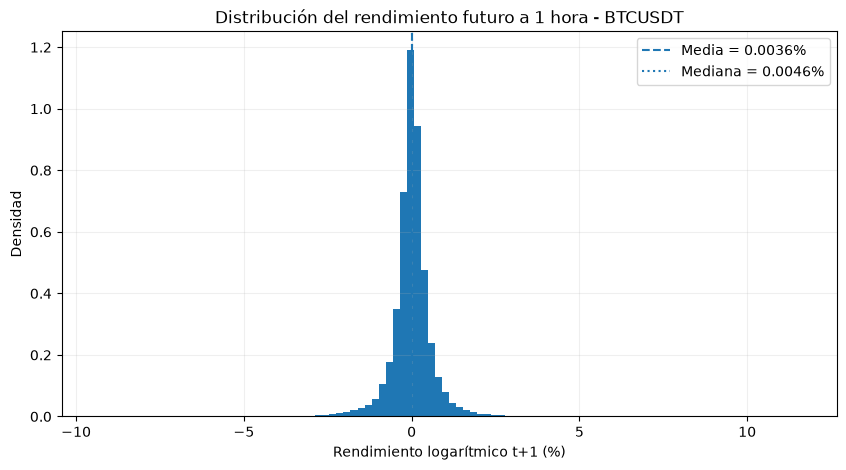

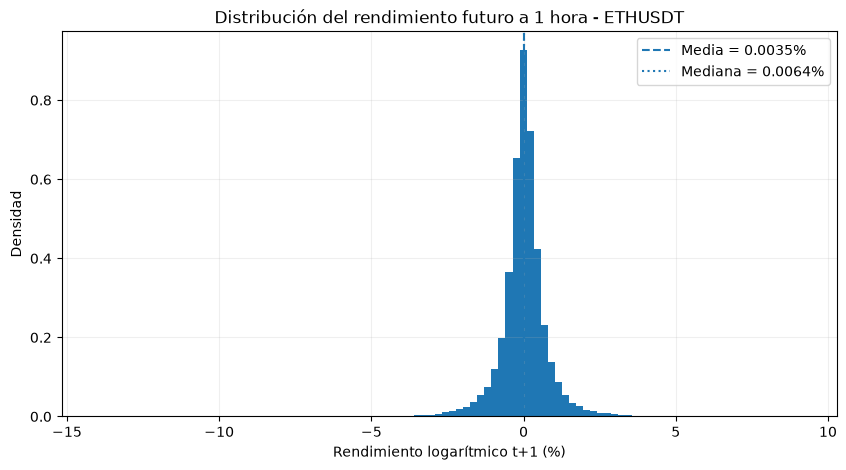

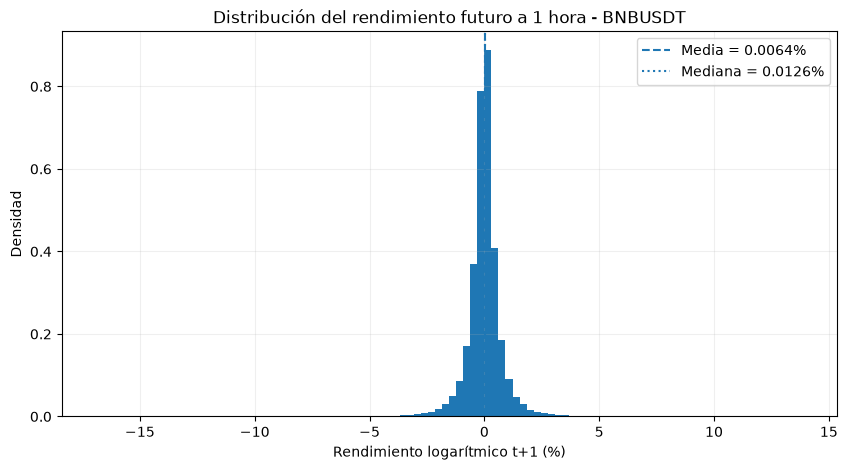

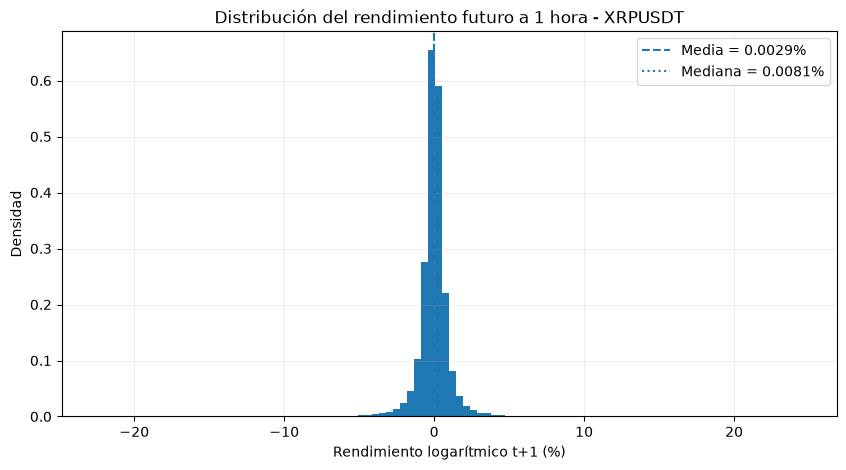

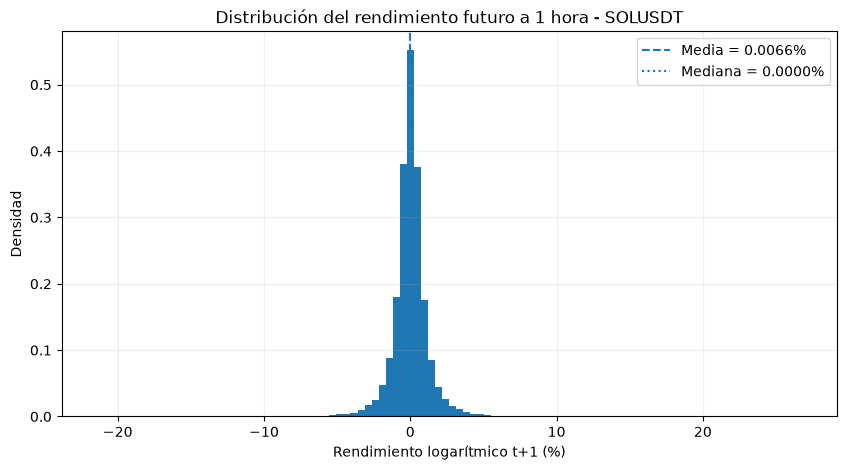

In [30]:
# ============================================================
# 2.1.4 HISTOGRAMAS DE LA VARIABLE OBJETIVO
# ============================================================

for symbol in SYMBOLS:

    temp = df_eda.loc[
        df_eda["symbol"] == symbol,
        "target_return_t1"
    ]

    plt.figure(figsize=(10, 5))

    plt.hist(
        temp,
        bins=100,
        density=True
    )

    plt.axvline(
        temp.mean(),
        linestyle="--",
        label=f"Media = {temp.mean():.4f}%"
    )

    plt.axvline(
        temp.median(),
        linestyle=":",
        label=f"Mediana = {temp.median():.4f}%"
    )

    plt.title(
        f"Distribución del rendimiento futuro a 1 hora - {symbol}"
    )

    plt.xlabel("Rendimiento logarítmico t+1 (%)")
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()

<Figure size 1100x600 with 0 Axes>

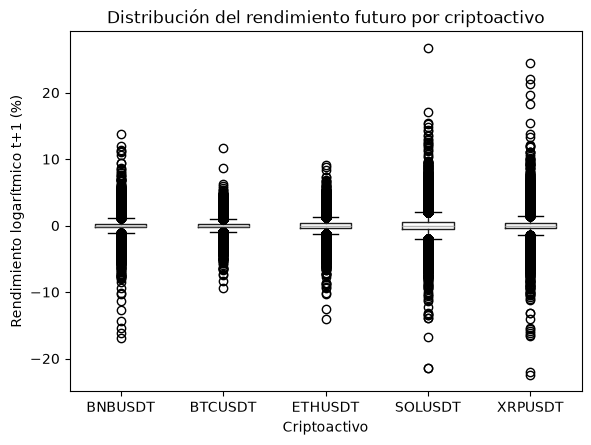

In [31]:
# ============================================================
# 2.1.5 BOXPLOT DE LA VARIABLE OBJETIVO
# ============================================================

plt.figure(figsize=(11, 6))

df_eda.boxplot(
    column="target_return_t1",
    by="symbol",
    grid=False
)

plt.title(
    "Distribución del rendimiento futuro por criptoactivo"
)
plt.suptitle("")

plt.xlabel("Criptoactivo")
plt.ylabel("Rendimiento logarítmico t+1 (%)")

plt.show()

## 2.2 Análisis unidimensional

El análisis unidimensional tiene como objetivo estudiar individualmente las
variables disponibles en el dataset antes de analizar relaciones entre ellas.

Para cada variable se evaluarán:

- Tipo de variable.
- Cardinalidad.
- Valores faltantes.
- Estadísticos descriptivos.
- Dispersión.
- Asimetría.
- Curtosis.
- Distribución.
- Presencia de valores extremos.

Las variables auxiliares utilizadas exclusivamente para controlar la continuidad
temporal, como `time_diff`, `gap_before` y `segment_id`, no serán consideradas
variables predictoras del modelo.